# Rest Day Impact on Shooting
Quantifies how fatigue (back-to-backs vs. full rest) affects FG%, 3P%, and scoring.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

players = pd.read_csv('../data/fact_player_games.csv')
schedule = pd.read_csv('../data/dim_schedule.csv')

print("players:", players.shape)
print("schedule:", schedule.shape)
schedule.head()

players: (30000, 30)
schedule: (2802, 10)


,GAME_ID,GAME_DATE,SEASON_ID,TEAM_ID,OPP_TEAM_ID,IS_HOME,PREV_GAME_DATE,DAYS_REST,IS_BACK_TO_BACK,NEXT_GAME_DATE
0,42400407,2025-06-22,42024,1610612754,1610612760,0,2025-06-19,3,0,NaN
1,42400407,2025-06-22,42024,1610612760,1610612754,1,2025-06-19,3,0,NaN
2,42400406,2025-06-19,42024,1610612754,1610612760,1,2025-06-16,3,0,2025-06-22
3,42400406,2025-06-19,42024,1610612760,1610612754,0,2025-06-16,3,0,2025-06-22
4,42400405,2025-06-16,42024,1610612760,1610612754,1,2025-06-13,3,0,2025-06-19


## Step 1: Join & Filter
Join `fact_player_games` with `dim_schedule` on `(GAME_ID, TEAM_ID)` to bring in `DAYS_REST`. Apply the same avg-minutes filter used in other explorations (avg MIN >= 10).

In [10]:
df = players.merge(
    schedule[['GAME_ID', 'TEAM_ID', 'DAYS_REST']],
    on=['GAME_ID', 'TEAM_ID'],
    how='inner'
)

# Drop players who average fewer than 10 minutes
avg_min = df.groupby('PLAYER_ID')['MIN'].mean()
qualified_ids = avg_min[avg_min >= 10].index
df = df[df['PLAYER_ID'].isin(qualified_ids)].copy()

print(f"{df['PLAYER_ID'].nunique()} players, {len(df)} game-rows after filter")
print(df['DAYS_REST'].value_counts().sort_index())

510 players, 27280 game-rows after filter
DAYS_REST
0      185
1     4411
2    16517
3     3981
4      833
5      554
6      304
7      162
8      276
9       57
Name: count, dtype: int64


## Step 2: Bucket DAYS_REST
Group into four buckets: **0** (back-to-back), **1**, **2**, **3+**.

In [11]:
def rest_bucket(d):
    if d == 0:   return '0 (B2B)'
    if d == 1:   return '1'
    if d == 2:   return '2'
    return '3+'

df['rest_bucket'] = df['DAYS_REST'].apply(rest_bucket)

BUCKET_ORDER = ['0 (B2B)', '1', '2', '3+']
df['rest_bucket'] = pd.Categorical(df['rest_bucket'], categories=BUCKET_ORDER, ordered=True)

df['rest_bucket'].value_counts().reindex(BUCKET_ORDER)

rest_bucket
0 (B2B)      185
1           4411
2          16517
3+          6167
Name: count, dtype: int64

## Step 3: Summary Table
Mean and median FG%, 3P%, and PTS per rest bucket.

In [12]:
summary = (
    df.groupby('rest_bucket', observed=True)[['FG_PCT', 'FG3_PCT', 'PTS']]
    .agg(['mean', 'median', 'count'])
)
summary.columns = ['_'.join(c) for c in summary.columns]

# Format for display without jinja2
fmt = summary.copy()
for col in ['FG_PCT_mean', 'FG_PCT_median', 'FG3_PCT_mean', 'FG3_PCT_median']:
    fmt[col] = fmt[col].map('{:.1%}'.format)
for col in ['PTS_mean', 'PTS_median']:
    fmt[col] = fmt[col].map('{:.1f}'.format)
for col in ['FG_PCT_count', 'FG3_PCT_count', 'PTS_count']:
    fmt[col] = fmt[col].map('{:.0f}'.format)
fmt

,FG_PCT_mean,FG_PCT_median,FG_PCT_count,FG3_PCT_mean,FG3_PCT_median,FG3_PCT_count,PTS_mean,PTS_median,PTS_count
rest_bucket,,,,,,,,,
0 (B2B),49.3%,50.0%,180,32.4%,31.6%,150,6.9,6.0,185
1,45.3%,45.5%,4265,33.1%,33.3%,3630,11.3,10.0,4411
2,45.9%,46.7%,15961,33.8%,33.3%,13711,11.3,10.0,16517
3+,45.5%,46.7%,5911,33.5%,33.3%,5013,11.0,9.0,6167


## Step 4: Boxplots — FG%, 3P%, and PTS by Rest Bucket
Each box shows the per-game distribution across all qualifying player-games in that rest bucket.

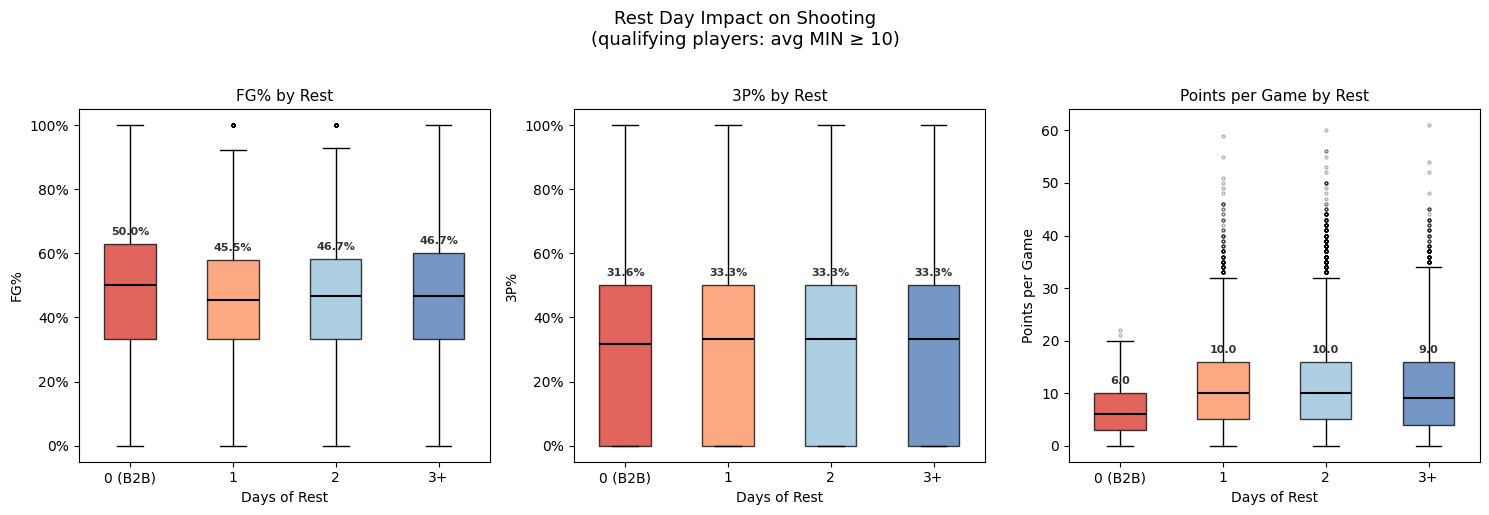

In [13]:
STATS = [
    ('FG_PCT',  'FG%',            True),
    ('FG3_PCT', '3P%',            True),
    ('PTS',     'Points per Game', False),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']  # warm → cool = less → more rest

for ax, (col, label, pct_fmt) in zip(axes, STATS):
    data_by_bucket = [
        df.loc[df['rest_bucket'] == b, col].dropna().values
        for b in BUCKET_ORDER
    ]

    bp = ax.boxplot(
        data_by_bucket,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        flierprops=dict(marker='o', markersize=2, alpha=0.3, linestyle='none'),
        widths=0.5,
    )

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    # Annotate median values above each box
    for i, (vals, color) in enumerate(zip(data_by_bucket, colors), start=1):
        med = np.median(vals)
        label_txt = f'{med:.1%}' if pct_fmt else f'{med:.1f}'
        ax.text(i, np.percentile(vals, 75) + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.02,
                label_txt, ha='center', va='bottom', fontsize=8, fontweight='bold', color='#333')

    ax.set_xticks(range(1, len(BUCKET_ORDER) + 1))
    ax.set_xticklabels(BUCKET_ORDER, fontsize=10)
    ax.set_xlabel('Days of Rest', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'{label} by Rest', fontsize=11)
    if pct_fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))

fig.suptitle('Rest Day Impact on Shooting\n(qualifying players: avg MIN ≥ 10)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Step 5: Mean Trend Line
Plot the mean of each stat across rest buckets to make the fatigue gradient easier to read at a glance.

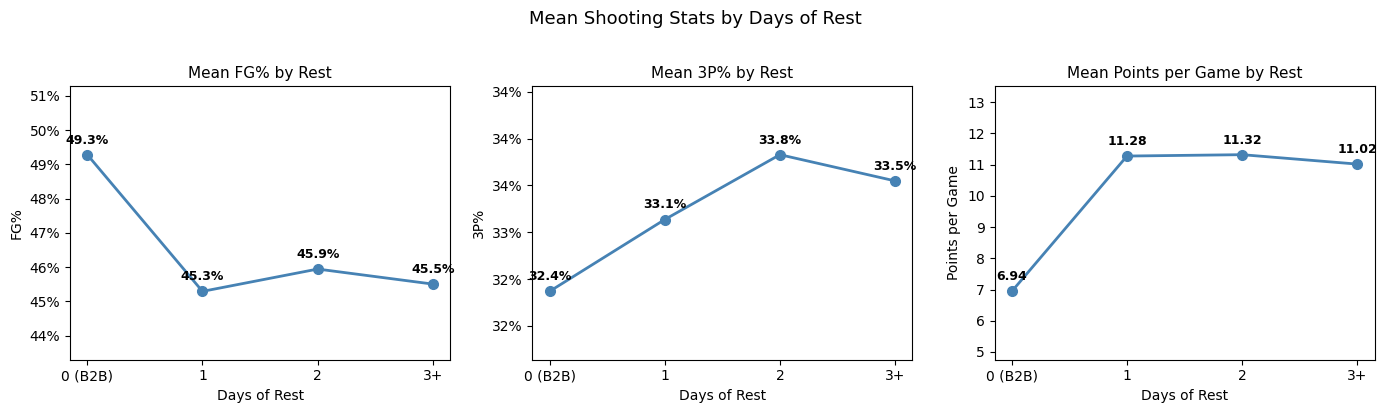

In [14]:
means = (
    df.groupby('rest_bucket', observed=True)[['FG_PCT', 'FG3_PCT', 'PTS']]
    .mean()
    .reindex(BUCKET_ORDER)
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, label, pct_fmt) in zip(axes, STATS):
    vals = means[col].values
    ax.plot(BUCKET_ORDER, vals, marker='o', color='steelblue', linewidth=2, markersize=7)

    for x, y in enumerate(vals):
        txt = f'{y:.1%}' if pct_fmt else f'{y:.2f}'
        ax.annotate(txt, (x, y), textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, fontweight='bold')

    ax.set_xlabel('Days of Rest', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f'Mean {label} by Rest', fontsize=11)
    if pct_fmt:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0%}'))
    margin = (vals.max() - vals.min()) * 0.5 or 0.01
    ax.set_ylim(vals.min() - margin, vals.max() + margin)

fig.suptitle('Mean Shooting Stats by Days of Rest', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()